In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import the refactored TrendAnalyzer
from soros_system.main import TrendAnalyzer
from soros_system.analysis.markov_vol_model import MarkovVolModel


# Define asset IDs and paths to your data
asset_ids = [
    'bitcoin', 'ethereum', 'solana', 'ripple'
    # Add more assets as needed
]

data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/'
btc_data_path='/Users/valter.rebelo/MissionControl/data/micro/candleData/bitcoin_candles.csv'
ssr_data_path='/Users/valter.rebelo/MissionControl/data/onchainData/BTC_SSR.csv'
markov_vol_model = MarkovVolModel.load_model_by_timestamp('20250325_144631')


analyzer = TrendAnalyzer(
    asset_ids=asset_ids,
     data_path=data_path,
     btc_data_path=btc_data_path,
     lookback_days='all',
     ssr_data_path=ssr_data_path,        
     markov_analyzer=markov_vol_model  
 )

# Analyze all assets
results = analyzer.analyze_multiple_assets()


Detected MarkovVolModel passed as markov_analyzer - using it for volatility analysis


Analyzing assets:   0%|          | 0/4 [00:00<?, ?it/s]

Classifying bitcoin:   0%|          | 0/1 [00:00<?, ?it/s]

Creating trend data for bitcoin:   0%|          | 0/2 [00:00<?, ?it/s]

Classifying ethereum:   0%|          | 0/1 [00:00<?, ?it/s]

...

Creating trend data for solana:   0%|          | 0/2 [00:00<?, ?it/s]

Classifying ripple:   0%|          | 0/1 [00:00<?, ?it/s]

Creating trend data for ripple:   0%|          | 0/2 [00:00<?, ?it/s]

Computing metrics:   0%|          | 0/4 [00:00<?, ?it/s]

Column overall_trend_BTC not found in data for bitcoin. Skipping BTC trend metrics calculation.


In [ ]:
# Get processed data for Cardano
eth_processed = analyzer.get_asset_processed_data('ethereum')
eth_processed  # See available columns including trend classifications

In [3]:
info = analyzer.get_asset_information('ethereum')
short_term_matrix = info.get('transition_matrix_usd_short_term')
medium_term_matrix = info.get('transition_matrix_usd_medium_term')
long_term_matrix = info.get('transition_matrix_usd_long_term')
overall_matrix = info.get('transition_matrix_usd_overall')

In [ ]:
info = analyzer.get_asset_information('ethereum')
info.get('transition_matrix_usd')
trends_usd = info.get('consolidated_trend_metrics_usd')
positive_usd_trends = trends_usd[(trends_usd['Sortino'] > 0) & 
                         (trends_usd['Sharpe'] > 0) & 
                         (trends_usd['Return_Skew'] > 0) & 
                         (trends_usd['Avg_Return'] > 0) & 
                         (trends_usd['Median_Return'] > 0)]
positive_usd_trends
trends_btc = info.get('consolidated_trend_metrics_btc')
positive_btc_trends = trends_btc[(trends_btc['Sortino'] > 0) & 
                         (trends_btc['Sharpe'] > 0) & 
                         (trends_btc['Return_Skew'] > 0) & 
                         (trends_btc['Avg_Return'] > 0) &   
                         (trends_btc['Median_Return'] > 0)]
positive_btc_trends

# Get the processed data to analyze concurrent trends
solana_data = analyzer.get_asset_processed_data('ethereum')

# Extract positive trend conditions for USD
positive_usd_trend_conditions = []
for _, row in positive_usd_trends.iterrows():
    term = row['Term'].lower().replace(' ', '_')
    trend = row['Trend']
    positive_usd_trend_conditions.append((f"{term}_trend_USD", trend))

# Extract positive trend conditions for BTC
positive_btc_trend_conditions = []
for _, row in positive_btc_trends.iterrows():
    term = row['Term'].lower().replace(' ', '_')
    trend = row['Trend']
    positive_btc_trend_conditions.append((f"{term}_trend_BTC", trend))

# Create masks for each condition
usd_masks = []
for col, trend in positive_usd_trend_conditions:
    if col in solana_data.columns:
        usd_masks.append(solana_data[col] == trend)

btc_masks = []
for col, trend in positive_btc_trend_conditions:
    if col in solana_data.columns:
        btc_masks.append(solana_data[col] == trend)

# Calculate concurrent trends if we have valid conditions
if usd_masks and btc_masks:
    # Combine all USD positive trend conditions with OR
    usd_positive = pd.concat(usd_masks, axis=1).any(axis=1)
    
    # Combine all BTC positive trend conditions with OR
    btc_positive = pd.concat(btc_masks, axis=1).any(axis=1)
    
    # Calculate concurrent positive trends
    concurrent_positive = usd_positive & btc_positive
    
    # Calculate percentages
    total_days = len(solana_data)
    usd_positive_pct = usd_positive.mean() * 100
    btc_positive_pct = btc_positive.mean() * 100
    concurrent_positive_pct = concurrent_positive.mean() * 100
    
    print(f"USD positive trends: {usd_positive_pct:.2f}% of the time")
    print(f"BTC positive trends: {btc_positive_pct:.2f}% of the time")
    print(f"Concurrent positive trends: {concurrent_positive_pct:.2f}% of the time")
    print(f"Percentage of USD positive trends that are also BTC positive: {(concurrent_positive_pct/usd_positive_pct*100) if usd_positive_pct > 0 else 0:.2f}%")
    print(f"Percentage of BTC positive trends that are also USD positive: {(concurrent_positive_pct/btc_positive_pct*100) if btc_positive_pct > 0 else 0:.2f}%")
else:
    print("Not enough data to calculate concurrent trends")


In [ ]:
analyzer.get_asset_information('ethereum', lookback_days=365)

In [ ]:
asset = 'bitcoin'

info = analyzer.get_asset_information(asset, lookback_days=730)


info.get('transition_matrix_usd')
trends_usd = info.get('consolidated_trend_metrics_usd')
positive_usd_trends = trends_usd[(trends_usd['Sortino'] > 0) & 
                         (trends_usd['Sharpe'] > 0) & 
                         (trends_usd['Return_Skew'] > 0) & 
                         (trends_usd['Avg_Return'] > 0) & 
                         (trends_usd['Median_Return'] > 0)]
positive_usd_trends.sort_values(by='Sortino', ascending=False)

In [ ]:
info = analyzer.get_asset_information(asset, lookback_days=730)


info.get('transition_matrix_btc')
trends_btc = info.get('consolidated_trend_metrics_btc')
positive_btc_trends = trends_btc[(trends_btc['Sortino'] > 0) & 
                         (trends_btc['Sharpe'] > 0) & 
                         (trends_btc['Return_Skew'] > 0) & 
                         (trends_btc['Avg_Return'] > 0) & 
                         (trends_btc['Median_Return'] > 0)]
positive_btc_trends.sort_values(by='Sortino', ascending=False)

In [3]:
analyzer.create_portfolio(
    'trend_optimist',
    #btc_trend_gating=1,
    usd_conditions={'Short Term': [-2,-1,0,1,2]},
    #btc_conditions={'Short Term': ['Strong Bull']},
    rsi_conditions_usd=True,
    rsi_conditions_btc=False,
    use_volatility_filter=True,
    use_ssr_signal=True,
    volatility_weight=1,
    btc_only=True,
    signal_threshold=0
)

analyzer.create_portfolio(
    'big_wins_i',
    usd_conditions={'Short Term': [-2, -1, 0, 1, 2]},
    btc_conditions={'Short Term': [2], 'Overall': [2]},
    rsi_conditions_usd=True,
    rsi_conditions_btc=True,
    use_btc_rsi_signal=False,
    follow_portfolio='trend_optimist',
    use_volatility_filter=True,
    use_ssr_signal=False,
    #use_ssr_gate=True,
    volatility_weight=1,
    btc_only=False,
    signal_threshold=50
)


Portfolio 'trend_optimist' already exists. Overwriting.
Portfolio 'big_wins_i' already exists. Overwriting.                         


True

In [9]:
# Get asset-specific performance metrics
backtest_results = analyzer.backtest_portfolio('trend_optimist', '2023-12-31', '2025-12-31')
backtest_results.get('results').keys()

dict_keys(['bitcoin'])

<Axes: xlabel='date'>

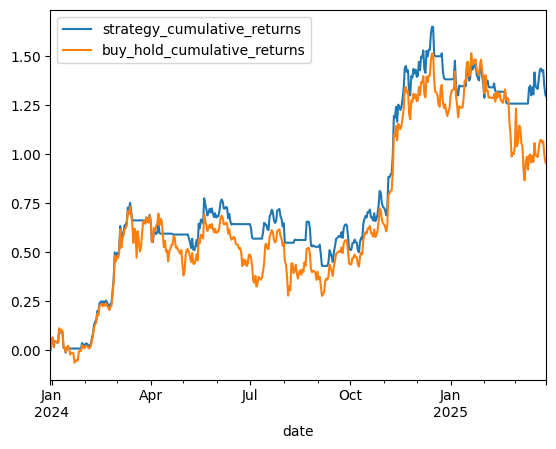

In [12]:
# Get the bitcoin results data
bitcoin_results = backtest_results.get('results').get('bitcoin')
# Plot with date as x-axis
bitcoin_results.set_index('date')[['strategy_cumulative_returns', 'buy_hold_cumulative_returns']].plot()

In [13]:
backtest_results.get('metrics').get('bitcoin')

,Strategy,Buy & Hold
Total Return (%),129.175962,95.170273
Max Drawdown (%),19.444156,26.231908
Sharpe Ratio,0.098419,0.06711
Sortino Ratio,0.142555,0.108122
Annualized Volatility (%),39.442365,52.344164
Annualized Return (%),109.778164,95.522919
Total Trades,26.000000,-
Win Rate (%),53.846154,-
Avg Win (%),11.000714,-
Avg Loss (%),-3.885000,-


In [ ]:
backtest_results.get('trades').get('bitcoin')

In [18]:
backtest_results.get('basket_selection')

,date,bitcoin
0,2023-12-31,1
1,2024-01-01,1
2,2024-01-02,0
3,2024-01-03,0
4,2024-01-04,0
...,...,...
451,2025-03-26,1
452,2025-03-27,1
453,2025-03-28,1
454,2025-03-29,1
